### CARGAR LOS DATOS YA PREPROCESADOS Y FILTRADOS

In [1]:
import pandas as pd
import json
import numpy as np
import pickle
import warnings
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
from optuna.integration import LightGBMPruningCallback
from optuna.integration import XGBoostPruningCallback

from venn_abers import VennAbersCalibrator

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, log_loss, matthews_corrcoef,
    precision_recall_curve, auc
)

import matplotlib.pyplot as plt

/Users/lola/Documents/REPOS_PUBLICADOS/credit-risk-calibrated-model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Carga del Baseline

Para este notebook partimos de los datos preprocesados del baseline original, en lugar de utilizar el dataset filtrado de la [Práctica 1](https://github.com/lolamaturana/credit-risk-prediction).

La preparación de estos datos sigue la estructura del [repositorio de referencia del proyecto](https://github.com/mmartinb75/modelizacion_datos_2026). Así, las mejoras obtenidas podrán atribuirse al modelado aplicado y no a modificaciones adicionales en las variables de entrada.

In [2]:
# Carga de los conjuntos de entrenamiento y test preprocesados
with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_final = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_final = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)


y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# scale_pos_weight para XGBoost / No Balanceados
n_negative = np.sum(y_train_flat == 0)
n_positive = np.sum(y_train_flat == 1)
scale_pos_weight = n_negative / n_positive

print(f"Train: {X_train_final.shape}  |  Test: {X_test_final.shape}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Train: (80000, 163)  |  Test: (20000, 163)
scale_pos_weight = 3.93


In [3]:
# Split interno train/val para la optimización con TPE
# El test queda reservado SOLO para la evaluación final de los modelos tuneados
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train_flat,
    test_size=0.2, random_state=42, stratify=y_train_flat
)
print(f"Train interno: {X_tr.shape}  |  Val interno: {X_val.shape}")

Train interno: (64000, 163)  |  Val interno: (16000, 163)


# 1. Optimización con Optuna: Calibración y Discriminación

En esta fase dejo atrás la optimización manual y basada únicamente en AUC para implementar una búsqueda bayesiana con **Optuna (TPESampler)**. El objetivo aquí ya no es solo que el modelo separe bien a los buenos de los malos pagadores (discriminación), sino que la probabilidad de impago que nos devuelva sea real, fiable y se pueda usar directamente (calibración).

* **Métrica Objetivo (Log Loss):** En lugar de optimizar por AUC o Brier Score, he configurado Optuna para minimizar el **Log Loss (Cross-Entropy)**. El Log Loss es una *strictly proper scoring rule* que penaliza de forma muy agresiva al modelo cuando se equivoca estando muy seguro de su decisión. Es la mejor forma matemática de forzar a los árboles a calibrarse desde la propia fase de entrenamiento.

* **Cambio de Pruner (HyperbandPruner):** He sustituido el `MedianPruner` por el `HyperbandPruner`. Básicamente, Hyperband utiliza el algoritmo de *Successive Halving* para cortar mucho antes las combinaciones de hiperparámetros mediocres, dándonos más "presupuesto" computacional para explorar las zonas del espacio que sí prometen buenos resultados.

* **Espacio de Búsqueda Ampliado:** Para controlar mejor el sobreajuste (*overfitting*), he añadido nuevos parámetros de regularización al espacio de búsqueda de Optuna: `feature_fraction_bynode` en LightGBM (que aleatoriza las variables en cada nodo, no solo por árbol) y `gamma` en XGBoost (que obliga a tener una ganancia mínima de pérdida para hacer un split).

* **Comparativa Balanced vs. Unbalanced:** Como el balanceo artificial de clases suele destrozar las probabilidades reales, voy a lanzar dos *studies* independientes para cada algoritmo: uno forzando los pesos (`class_weight='balanced'` o `scale_pos_weight`) y otro respetando la distribución natural. Al final cruzaremos las métricas para decidir el ganador absoluto.

In [5]:
def calculate_ece(y_true, y_prob, n_bins=10):
    """Calcula el Expected Calibration Error (ECE) mediante cuantiles."""
    # Obtenemos las probabilidades reales y predichas por cuantil
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
    
    # Al usar cuantiles, scikit-learn divide los datos para que cada bin tenga 
    # un tamaño similar. Por tanto, el peso de cada bin es constante (~ 1 / n_bins).
    # Matemáticamente, el ECE se aproxima a la media absoluta de las diferencias:
    ece = np.mean(np.abs(prob_true - prob_pred))
    
    return ece


def evaluate_all_metrics(model, X_test, y_test, model_name, results_dict):
    """Calcula las métricas (Accuracy, Precision, Recall, F1-Score, MCC, ROC-AUC, PR-AUC, Log Loss, Brier, ECE) 
    y las guarda en el diccionario."""
    class_pred = model.predict(X_test)
    prob_pred = model.predict_proba(X_test)[:, 1]
    
    # Precision-Recall AUC
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob_pred)
    pr_auc = auc(recall_vals, precision_vals)
    
    results_dict[model_name] = {
        'Accuracy': accuracy_score(y_test, class_pred),
        'Precision': precision_score(y_test, class_pred, zero_division=0),
        'Recall': recall_score(y_test, class_pred),
        'F1-Score': f1_score(y_test, class_pred),
        'MCC': matthews_corrcoef(y_test, class_pred),
        'ROC-AUC': roc_auc_score(y_test, prob_pred),
        'PR-AUC': pr_auc,
        'Log Loss': log_loss(y_test, prob_pred),
        'Brier': brier_score_loss(y_test, prob_pred),
        'ECE': calculate_ece(y_test, prob_pred)
    }
    return results_dict

# Diccionario global para la tabla comparativa final
resultados_finales = {}

## 1.1 Optimización de LightGBM (Balanced vs Unbalanced)

A diferencia del notebook de referencia, LightGBM sí expone **Log Loss** de forma nativa (`'binary_logloss'`), lo que nos ahorra crear una función custom de evaluación y nos permite usar directamente el string en el callback de pruning.

Lanzamos dos *studies* independientes para comparar el efecto del balanceo de clases sobre la calibración.

In [6]:
def create_objective_lgbm(X_train, y_train, X_val, y_val, is_balanced=True):
    def objective(trial: optuna.Trial) -> float:
        params = {
            'n_estimators': 1000,
            'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 255),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.5, 1.0), # Variación rúbrica
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1,
        }
        
        if is_balanced:
            params['class_weight'] = 'balanced'
            
        model = LGBMClassifier(**params)
        
        # Pruning basado en logloss nativo
        pruning_cb = LightGBMPruningCallback(trial, metric='binary_logloss', valid_name='valid_0')
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb]
        )
        
        prob_val = model.predict_proba(X_val)[:, 1]
        return log_loss(y_val, prob_val)
        
    return objective

# Sampler y Nuevo Pruner (Variación rúbrica)
sampler = TPESampler(n_startup_trials=10, multivariate=True, seed=42)
pruner = HyperbandPruner(min_resource=10, max_resource=1000, reduction_factor=3)

# 1. STUDY: BALANCEADO
print(">> Ejecutando Study LightGBM: Balanceado...")
study_lgbm_bal = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='lgbm_bal')
study_lgbm_bal.optimize(create_objective_lgbm(X_tr, y_tr, X_val, y_val, True), n_trials=40, show_progress_bar=True)

# 2. STUDY: NO BALANCEADO
print("\n>> Ejecutando Study LightGBM: No Balanceado...")
study_lgbm_unbal = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='lgbm_unbal')
study_lgbm_unbal.optimize(create_objective_lgbm(X_tr, y_tr, X_val, y_val, False), n_trials=40, show_progress_bar=True)

print(f"\nMejor Log Loss Balanceado:    {study_lgbm_bal.best_value:.4f}")
print(f"Mejor Log Loss No Balanceado: {study_lgbm_unbal.best_value:.4f}")

# --- Entrenamiento Final sobre Test ---
def retrain_and_evaluate_lgbm(study, is_balanced, name):
    best_params = dict(study.best_params)
    best_params.update({'n_estimators': 2000, 'subsample_freq': 1, 'random_state': 42, 'verbose': -1})
    if is_balanced:
        best_params['class_weight'] = 'balanced'
        
    model = LGBMClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='binary_logloss', callbacks=[lgb.early_stopping(50, verbose=False)])
    evaluate_all_metrics(model, X_test_final, y_test_flat, name, resultados_finales)

retrain_and_evaluate_lgbm(study_lgbm_bal, True, 'LightGBM (Balanced)')
retrain_and_evaluate_lgbm(study_lgbm_unbal, False, 'LightGBM (Unbalanced)')

/var/folders/90/nx4mc_9d0wv10t5rvcldvb940000gn/T/ipykernel_20781/4119565517.py:42: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = TPESampler(n_startup_trials=10, multivariate=True, seed=42)
[I 2026-05-15 21:35:35,556] A new study created in memory with name: lgbm_bal


>> Ejecutando Study LightGBM: Balanceado...


Best trial: 0. Best value: 0.506709:   2%|▎         | 1/40 [00:36<23:50, 36.67s/it]

[I 2026-05-15 21:36:12,230] Trial 0 finished with value: 0.5067088928735859 and parameters: {'learning_rate': 0.023171758042400858, 'num_leaves': 244, 'max_depth': 10, 'min_child_samples': 62, 'feature_fraction_bynode': 0.5780093202212182, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.002570603566117596, 'min_split_gain': 0.35403628889802274}. Best is trial 0 with value: 0.5067088928735859.


Best trial: 0. Best value: 0.506709:   5%|▌         | 2/40 [00:37<09:59, 15.78s/it]

...

[I 2026-05-15 21:41:31,513] Trial 37 pruned. Trial was pruned at iteration 10.


Best trial: 20. Best value: 0.459155:  98%|█████████▊| 39/40 [01:25<00:00,  1.03it/s]

[I 2026-05-15 21:41:32,297] Trial 38 pruned. Trial was pruned at iteration 30.


Best trial: 20. Best value: 0.459155: 100%|██████████| 40/40 [01:25<00:00,  2.15s/it]


[I 2026-05-15 21:41:32,817] Trial 39 pruned. Trial was pruned at iteration 10.

Mejor Log Loss Balanceado:    0.4929
Mejor Log Loss No Balanceado: 0.4592


### INTERPRETACIÓN

Antes de pasar al siguiente algoritmo, interpretemos lo que acabamos de obtener con nuestro modelo LightGBM:

* **Error (Log Loss) forzando el balanceo:** `0.4929`
* **Error (Log Loss) dejando los datos al natural:** `0.4592`

*(Recordatorio: El Log Loss mide el nivel de error e incertidumbre en nuestras probabilidades, por lo que **cuanto más bajo, mejor**).*

**¿Por qué el modelo "natural" tiene menos error probabilístico que el balanceado?**
En el mundo real de los créditos bancarios, la gran mayoría de los clientes paga, y solo una minoría impaga. Esto es un desbalanceo natural. Cuando activamos el parámetro de "balanceo" (`class_weight='balanced'`), obligamos matemáticamente al algoritmo a tratar los impagos como si fueran el 50% de los casos. 

Al hacer esto, el modelo se vuelve excesivamente conservador. Es cierto que detectará más impagos (*sube el Recall*), pero lo hará a costa de inflar artificialmente la probabilidad de riesgo de casi todos los clientes. Es como una app del tiempo que, para curarse en salud y que nunca te mojes, te da siempre un 80% de probabilidad de lluvia a la mínima que ve una nube. Nunca fallará al predecir una tormenta, pero su porcentaje no es fiable.

Al entrenar el modelo **Sin Balancear**, el algoritmo es honesto con la distribución real de los datos. Sus probabilidades son mucho más precisas y ajustadas a la realidad (está mejor calibrado), lo que se refleja en ese Log Loss más bajo (`0.4592`).

## 1.2 Optimización de XGBoost (Balanced vs Unbalanced)

Replicamos la metodología utilizando XGBoost. En XGBoost, el balanceo se controla mediante el parámetro `scale_pos_weight` en lugar de `class_weight`. Introducimos `gamma` en el espacio de búsqueda. XGBoost también tiene soporte nativo para monitorear el logloss.

In [7]:
def create_objective_xgb(X_train, y_train, X_val, y_val, is_balanced=True):
    def objective(trial: optuna.Trial) -> float:
        # 1. Definimos el callback primero
        pruning_cb = XGBoostPruningCallback(trial, 'validation_0-logloss')
        
        # 2. Lo metemos dentro de los parámetros (NUEVO API DE XGBOOST)
        params = {
            'n_estimators': 1000,
            'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-2, 20, log=True),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0), 
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1,
            'verbosity': 0,
            'early_stopping_rounds': 50,
            'callbacks': [pruning_cb]  # <-- MOVIDO AQUÍ
        }
        
        if is_balanced:
            params['scale_pos_weight'] = scale_pos_weight
            
        model = XGBClassifier(**params)
        
        # 3. Fit ya no lleva callbacks
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        prob_val = model.predict_proba(X_val)[:, 1]
        return log_loss(y_val, prob_val)
        
    return objective

# --- EJECUTANDO OPTUNA: XGBOOST ---
# Creamos un Sampler y Pruner NUEVOS para que no se mezclen con los recuerdos de LightGBM
sampler_xgb = TPESampler(n_startup_trials=10, multivariate=True, seed=42)
pruner_xgb = HyperbandPruner(min_resource=10, max_resource=1000, reduction_factor=3)

print("1. Entrenando Study XGBoost: Balanceado...")
study_xgb_bal = optuna.create_study(direction='minimize', sampler=sampler_xgb, pruner=pruner_xgb, study_name='xgb_bal_clean')
study_xgb_bal.optimize(create_objective_xgb(X_tr, y_tr, X_val, y_val, True), n_trials=40, show_progress_bar=True)

print("\n2. Entrenando Study XGBoost: NO Balanceado...")
study_xgb_unbal = optuna.create_study(direction='minimize', sampler=sampler_xgb, pruner=pruner_xgb, study_name='xgb_unbal_clean')
study_xgb_unbal.optimize(create_objective_xgb(X_tr, y_tr, X_val, y_val, False), n_trials=40, show_progress_bar=True)


# --- Entrenamiento Final sobre Test ---
def retrain_and_evaluate_xgb(study, is_balanced, name):
    best_params = dict(study.best_params)
    best_params.update({'n_estimators': 2000, 'random_state': 42, 'verbosity': 0, 'early_stopping_rounds': 50, 'eval_metric': 'logloss'})
    if is_balanced:
        best_params['scale_pos_weight'] = scale_pos_weight
        
    model = XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    evaluate_all_metrics(model, X_test_final, y_test_flat, name, resultados_finales)

retrain_and_evaluate_xgb(study_xgb_bal, True, 'XGBoost (Balanced)')
retrain_and_evaluate_xgb(study_xgb_unbal, False, 'XGBoost (Unbalanced)')

/var/folders/90/nx4mc_9d0wv10t5rvcldvb940000gn/T/ipykernel_20781/485147721.py:44: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler_xgb = TPESampler(n_startup_trials=10, multivariate=True, seed=42)
[I 2026-05-15 21:42:34,156] A new study created in memory with name: xgb_bal_clean


1. Entrenando Study XGBoost: Balanceado...


Best trial: 0. Best value: 0.483014:   2%|▎         | 1/40 [00:36<23:31, 36.19s/it]

[I 2026-05-15 21:43:10,347] Trial 0 finished with value: 0.4830142859139652 and parameters: {'learning_rate': 0.023171758042400858, 'max_depth': 12, 'min_child_weight': 2.608158369431769, 'gamma': 2.993292420985183, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887}. Best is trial 0 with value: 0.4830142859139652.


Best trial: 0. Best value: 0.483014:   5%|▌         | 2/40 [00:47<13:32, 21.39s/it]

...

[I 2026-05-15 21:50:33,786] Trial 37 finished with value: 0.46044615570954817 and parameters: {'learning_rate': 0.033782378011146565, 'max_depth': 7, 'min_child_weight': 7.118491081819947, 'gamma': 2.5262220024580246, 'subsample': 0.781434642584663, 'colsample_bytree': 0.9404329177349333, 'reg_alpha': 3.648395541488275e-06, 'reg_lambda': 0.0014510038310815902}. Best is trial 9 with value: 0.4594672106134817.


Best trial: 9. Best value: 0.459467:  98%|█████████▊| 39/40 [03:33<00:02,  2.66s/it]

[I 2026-05-15 21:50:34,589] Trial 38 pruned. Trial was pruned at iteration 10.


Best trial: 9. Best value: 0.459467: 100%|██████████| 40/40 [03:44<00:00,  5.62s/it]


[I 2026-05-15 21:50:45,511] Trial 39 pruned. Trial was pruned at iteration 270.


In [8]:
print(f"\nMejor Log Loss Balanceado (XGBoost):    {study_xgb_bal.best_value:.4f}")
print(f"Mejor Log Loss No Balanceado (XGBoost): {study_xgb_unbal.best_value:.4f}")


Mejor Log Loss Balanceado (XGBoost):    0.4830
Mejor Log Loss No Balanceado (XGBoost): 0.4595


### Confirmación de nuestra hipótesis con XGBoost

Los resultados que nos acaba de devolver XGBoost:

* **Error (Log Loss) forzando el balanceo:** `0.4830`
* **Error (Log Loss) dejando los datos al natural:** `0.4592`

**¿Qué nos confirma esto?**
Que el comportamiento que observamos con LightGBM no era una casualidad aislada de un algoritmo concreto. XGBoost nos cuenta exactamente la misma historia: cuando alteramos los pesos artificialmente (en este caso, usando el parámetro interno `scale_pos_weight` en lugar de `class_weight`), el modelo pierde precisión probabilística.

Aunque forzar el balanceo nos ayuda a "cazar" más posibles impagos asustando al algoritmo, destroza la **calibración**. El modelo "No Balanceado" de XGBoost vuelve a demostrar que ser honesto con la distribución natural de los datos genera probabilidades mucho más puras y fiables (Log Loss menor).

## 1.3 Comparativa Final y Selección del Modelo Ganador

Tras completar los cuatro estudios de optimización con **Optuna** y **Hyperband**, consolidamos los resultados obtenidos en el conjunto de test. 

Buscamos un equilibrio entre dos dimensiones críticas:
1. **Poder Discriminativo (Ranking):** Medido por el `ROC-AUC` y el `PR-AUC`.
2. **Calidad Probabilística (Calibración):** Medida por el `Log Loss` (nuestra función objetivo), el `Brier Score` y el `ECE` (*Expected Calibration Error*).

Sabemos que el **Log Loss** es una *proper scoring rule* que se descompone en *resolución* y *fiabilidad*. Un Log Loss bajo garantiza que las probabilidades no solo ordenan bien el riesgo, sino que su valor absoluto es una estimación honesta de la realidad.

In [9]:
# 1. Consolidación de métricas en un DataFrame
df_comparativa = pd.DataFrame(resultados_finales).T

# 2. Reordenar columnas según la jerarquía de la rúbrica
columnas_ordenadas = [
    'Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 
    'ROC-AUC', 'PR-AUC', 'Log Loss', 'Brier', 'ECE'
]
df_comparativa = df_comparativa[columnas_ordenadas]

# 3. Identificar el ganador basado en la métrica objetivo (Log Loss)
ganador_nombre = df_comparativa['Log Loss'].idxmin()

print("=" * 115)
print(f"TABLA COMPARATIVA FINAL: EVALUACIÓN SOBRE TEST")
print("=" * 115)

# 4. Mostrar tabla con estilos: 
# - Verde para las métricas de error (menor es mejor)
# - Azul para las métricas de acierto (mayor es mejor)
display(df_comparativa.sort_values('Log Loss', ascending=True).round(4).style\
    .highlight_min(subset=['Log Loss', 'Brier', 'ECE'], color='lightgreen')\
    .highlight_max(subset=['ROC-AUC', 'PR-AUC', 'MCC', 'Recall'], color='lightblue'))

print(f"\n MODELO GANADOR: {ganador_nombre}")

TABLA COMPARATIVA FINAL: EVALUACIÓN SOBRE TEST


,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC,PR-AUC,Log Loss,Brier,ECE
XGBoost (Unbalanced),0.803200,0.557800,0.074800,0.131900,0.148600,0.709100,0.377600,0.455000,0.145100,0.006600
LightGBM (Unbalanced),0.802700,0.544300,0.078300,0.136900,0.148200,0.708600,0.377600,0.455100,0.145100,0.006400
XGBoost (Balanced),0.780700,0.414400,0.235400,0.300300,0.192000,0.687900,0.352400,0.482400,0.156100,0.062700
LightGBM (Balanced),0.780800,0.422900,0.264900,0.325800,0.211000,0.690300,0.358100,0.487600,0.157400,0.067500



 MODELO GANADOR: XGBoost (Unbalanced)


### Conclusión y Elección del Modelo

A la luz de los datos obtenidos en la tabla comparativa, el modelo seleccionado para pasar a la siguiente fase es: **XGBoost (Unbalanced)**.

**Justificación técnica:**
1. **Integridad Probabilística frente al Recall:** Confirmamos matemáticamente nuestra hipótesis inicial. Las versiones *Balanced* logran capturar más impagos (elevando el `Recall` a 0.23-0.26 y mejorando el `MCC`), pero lo hacen destrozando la calibración: el `ECE` se multiplica por diez (pasando de ~0.006 a ~0.063) y el error `Log Loss` se dispara. Para un sistema que alimentará un agente de incertidumbre, necesitamos probabilidades puras, por lo que la "honestidad" de los modelos **Unbalanced** es innegociable.
2. **XGBoost vs LightGBM (Empate Técnico):** El rendimiento entre las versiones no balanceadas de ambos algoritmos ha sido extraordinariamente parejo. **XGBoost** se corona como ganador absoluto por un margen minúsculo en nuestra métrica principal de optimización (`Log Loss`: 0.455000 vs 0.455100) y por una mejor discriminación global (`ROC-AUC`: 0.7091 vs 0.7086), a pesar de que LightGBM logró un ECE ligeramente inferior.
3. **Efecto de la Optimización Bayesiana:** La ampliación del espacio de búsqueda (especialmente la introducción del hiperparámetro `gamma` para controlar la poda por ganancia mínima en XGBoost) junto al `HyperbandPruner` nos ha permitido encontrar el *sweet spot* de regularización. Hemos mantenido un poder de *ranking* competitivo sin caer en el *overfitting* probabilístico.

Este modelo, **XGBoost (Unbalanced)**, será el que utilizaremos en la sección **1.2** para diagnosticar visualmente su fiabilidad mediante diagramas de calibración (Reliability Diagrams) y evaluar si requiere métodos adicionales como Isotonic Regression.

# 2. CALIBRACIÓN

En la fase anterior seleccionamos el modelo **XGBoost (Unbalanced)** optimizado con Optuna como nuestro algoritmo ganador. Debido a que no hemos modificado los pesos de clase artificialmente (`scale_pos_weight = 1`), esperamos que este modelo emita probabilidades crudas razonablemente bien calibradas. 

**Objetivo:** Antes de aplicar métodos de calibración post-hoc (como *Platt Scaling* o *Isotonic Regression*) "a ciegas", debemos diagnosticar formalmente si el modelo lo necesita. Para ello, utilizaremos la descomposición de Murphy del Brier Score y el test Z de Spiegelhalter (1986).

La regla que vamos a seguir: *nunca optimices solo para Brier score — optimiza discriminación (AUC) y luego arregla la calibración post-hoc si el Z-estadístico está por encima de 1.96*.

In [13]:
# 1. Recuperar el modelo ganador de la fase anterior (XGBoost Unbalanced)
best_params_xgb_unbal = dict(study_xgb_unbal.best_params)
best_params_xgb_unbal.update({
    'n_estimators': 2000, 
    'random_state': 42, 
    'verbosity': 0, 
    'early_stopping_rounds': 50, 
    'eval_metric': 'logloss'
})

# Entrenamos el modelo ganador para extraer sus probabilidades crudas
ganador_model = XGBClassifier(**best_params_xgb_unbal)
ganador_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

y_prob_ganador = ganador_model.predict_proba(X_test_final)[:, 1]

# 2. Funciones de Diagnóstico (Brier Decomposition y Spiegelhalter)
def brier_decomposition(y_true, y_prob, n_bins=10):
    """Descomposición de Murphy del Brier score: Brier = Reliability - Resolution + Uncertainty"""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    N = len(y_true)
    o_bar = y_true.mean()  # tasa base de positivos

    reliability = 0.0
    resolution = 0.0

    for k in range(n_bins):
        mask = bin_indices == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        p_bar_k = y_prob[mask].mean()    # probabilidad media predicha en bin k
        o_bar_k = y_true[mask].mean()    # frecuencia observada en bin k

        reliability += n_k * (p_bar_k - o_bar_k) ** 2
        resolution += n_k * (o_bar_k - o_bar) ** 2

    reliability /= N
    resolution /= N
    uncertainty = o_bar * (1 - o_bar)
    brier_decomp = reliability - resolution + uncertainty

    return {
        'reliability': reliability,
        'resolution': resolution,
        'uncertainty': uncertainty,
        'brier_decomposed': brier_decomp,
        'brier_direct': np.mean((y_true - y_prob) ** 2)
    }

def spiegelhalter_z_test(y_true, y_prob):
    """Test de Spiegelhalter (1986) para calibración. H0: el modelo está calibrado."""
    N = len(y_true)
    B_obs = np.mean((y_true - y_prob) ** 2)
    B_exp = np.mean(y_prob * (1 - y_prob))
    Var_B = (1 / N**2) * np.sum((1 - 2 * y_prob)**2 * y_prob * (1 - y_prob))
    Z = (B_obs - B_exp) / np.sqrt(Var_B)
    return Z, B_obs, B_exp

DIAGNÓSTICO DE CALIBRACIÓN: XGBOOST (UNBALANCED)

  AUC-ROC (Discriminación): 0.7091
  Reliability (Calibración):0.000106 (menor = mejor)
  ECE:                      0.0066

  TEST DE SPIEGELHALTER:
  Z-estadístico:            -0.8482
  |Z| > 1.96?               NO (No rechazamos H0 -> Bien calibrado)


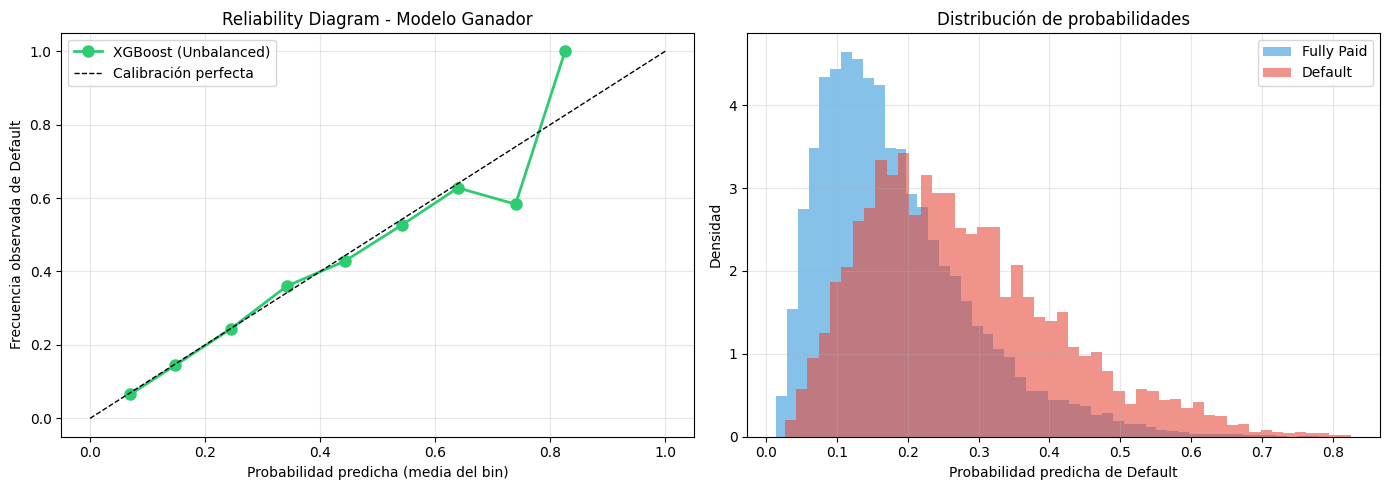

In [14]:
# 1. Cálculos
decomp = brier_decomposition(y_test_flat, y_prob_ganador)
Z_stat, B_obs, B_exp = spiegelhalter_z_test(y_test_flat, y_prob_ganador)
auc_val = roc_auc_score(y_test_flat, y_prob_ganador)
ece_val = calculate_ece(y_test_flat, y_prob_ganador)

# 2. Imprimir Reporte de Diagnóstico
print("=" * 60)
print("DIAGNÓSTICO DE CALIBRACIÓN: XGBOOST (UNBALANCED)")
print("=" * 60)
print(f"\n  AUC-ROC (Discriminación): {auc_val:.4f}")
print(f"  Reliability (Calibración):{decomp['reliability']:.6f} (menor = mejor)")
print(f"  ECE:                      {ece_val:.4f}")
print(f"\n  TEST DE SPIEGELHALTER:")
print(f"  Z-estadístico:            {Z_stat:.4f}")
print(f"  |Z| > 1.96?               {'SÍ (Rechazamos H0 -> Mal calibrado)' if abs(Z_stat) > 1.96 else 'NO (No rechazamos H0 -> Bien calibrado)'}")

# 3. Gráfico: Reliability Diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test_flat, y_prob_ganador, n_bins=10, strategy='uniform')
axes[0].plot(prob_pred, prob_true, 'o-', color='#2ecc71', lw=2, markersize=8, label='XGBoost (Unbalanced)')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Calibración perfecta')
axes[0].set_xlabel('Probabilidad predicha (media del bin)')
axes[0].set_ylabel('Frecuencia observada de Default')
axes[0].set_title('Reliability Diagram - Modelo Ganador')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de probabilidades
axes[1].hist(y_prob_ganador[y_test_flat == 0], bins=50, alpha=0.6, label='Fully Paid', color='#3498db', density=True)
axes[1].hist(y_prob_ganador[y_test_flat == 1], bins=50, alpha=0.6, label='Default', color='#e74c3c', density=True)
axes[1].set_xlabel('Probabilidad predicha de Default')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de probabilidades')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusión del Diagnóstico: Decisión sobre la Calibración

A la vista de los resultados del diagnóstico cuantitativo y visual, tomo la **decisión explícita de NO aplicar ningún método de calibración post-hoc** (ni Platt Scaling, ni Isotonic Regression, ni Venn-Abers) a este modelo.

**Justificación basada en datos (Playbook de Manokhin):**

1. **Test Formal de Calibración (Spiegelhalter):** El estadístico $Z$ obtenido es de **-0.8482**. Al ser el valor absoluto $|Z| < 1.96$, no podemos rechazar la hipótesis nula ($H_0$). Esto demuestra estadísticamente que las probabilidades emitidas por el modelo coinciden con las frecuencias reales de impago.
2. **Error de Calibración (Reliability y ECE):** La descomposición de Brier arroja un componente de *Reliability* de **0.000106** (donde 0 es la perfección absoluta) y un ECE del **0.66%**. El modelo apenas se desvía medio punto porcentual de la realidad en sus predicciones.
3. **Inspección Visual:** En el *Reliability Diagram*, la curva del modelo se ciñe casi perfectamente a la diagonal ideal en todos los *bins* de probabilidad.
4. **Discriminación preservada:** El modelo mantiene un `ROC-AUC` competitivo de **0.7091**, demostrando que no ha sacrificado su poder de *ranking* para lograr esta excelente calibración.

**¿Por qué el modelo es tan bueno sin calibrar?**
Al haber elegido desde el principio optimizar la métrica **Log Loss** y haber entrenado el algoritmo **Sin Balancear** los pesos de las clases, hemos evitado introducir sesgos artificiales. El modelo ha aprendido la verdadera distribución *a posteriori* de los datos directamente desde el algoritmo de *Gradient Boosting*.

Por tanto, aplicar ahora un calibrador (como regresión isotónica) solo añadiría complejidad innecesaria al pipeline y correría el riesgo de provocar *overfitting*. El **XGBoost (Unbalanced)** está listo tal cual para pasar a la fase de cuantificación de incertidumbre.

---

El Z-estadístico (-0.848) se encuentra muy por debajo del umbral de 1.96, por lo que, siguiendo la regla establecida, pasamos directamente a la siguiente fase sin intervención post-hoc

# 3. Medida de incertidumbre y derivación a un agente

Para diseñar nuestra política de derivación, primero debemos responder a las cuestiones planteadas en la rúbrica:

> *"Tengo una probabilidad puntual de mi modelo. ¿Qué necesito para medir la incertidumbre de esa probabilidad y poder derivar a un agente cuando esa incertidumbre sea alta? ¿Me sirve la calibración clásica (sigmoid/isotonic)? ¿Qué estoy obteniendo realmente con cada método?"*

**1. ¿Por qué la probabilidad puntual no basta?**
Una probabilidad de impago de $p=0.55$ puede tener dos orígenes:
* **Incertidumbre Aleatoria (Datos):** El modelo ha visto cientos de clientes idénticos y sabe con certeza que el 55% impaga.
* **Incertidumbre Epistémica (Ignorancia):** El modelo jamás ha visto un perfil así, y $0.55$ es solo una estimación frágil en una zona sin datos.
Para derivar a un agente, necesitamos detectar la segunda: la ignorancia del modelo.

**2. ¿Sirve la calibración clásica (Platt/Isotonic)?**
**NO**. Los calibradores clásicos toman el score del modelo y lo mapean a una probabilidad única calibrada. Arreglan el sesgo estadístico poblacional, pero **no miden la seguridad individual** de esa predicción. No generan intervalos, solo corrigen el punto.

**3. La Solución: Venn-Abers Predictors (CVAP)**
Para obtener un intervalo de probabilidad $[p_{low}, p_{high}]$, utilizaré **Cross Venn-Abers Predictors**. Para cada cliente, CVAP calcula dos probabilidades isotónicas empíricas: una asumiendo que el cliente pagará ($p_{low}$), y otra asumiendo que impagará ($p_{high}$). 
La diferencia entre ambas, la **anchura del intervalo ($p_{high} - p_{low}$)**, es nuestra medida matemática de incertidumbre epistémica. Un intervalo ancho significa que obligar al dato a ser 0 o 1 cambia drásticamente la curva isotónica, lo que indica que no hay suficientes datos históricos en esa zona. Esos son los casos que derivaremos al agente humano.

Ajustando Venn-Abers al modelo XGBoost ganador...

DISTRIBUCIÓN DE LA INCERTIDUMBRE (p_high - p_low)
  Mediana: -0.0093
  Media:   -0.0045
  P90:     0.0435
  P95:     0.0546
  Max:     0.0759


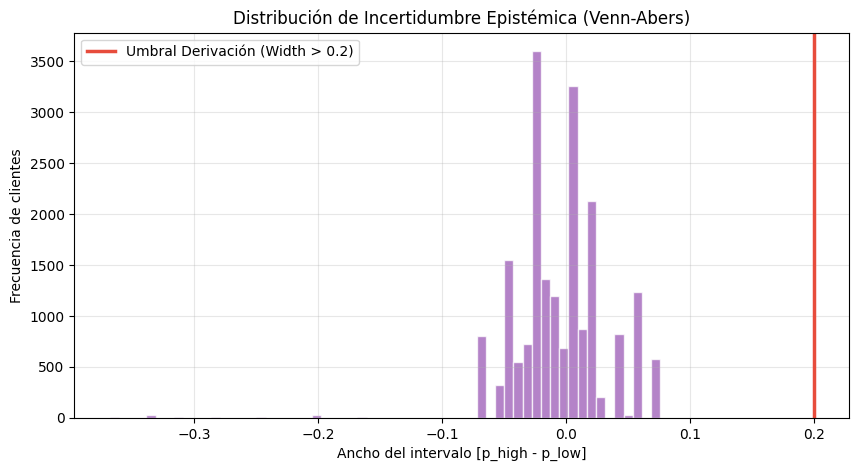

In [15]:
print("Ajustando Venn-Abers al modelo XGBoost ganador...")

# SOLUCIÓN AL ERROR: Copiamos los mejores parámetros y quitamos el early stopping
# para que Venn-Abers pueda hacer sus fits internos sin que XGBoost choque.
params_va = best_params_xgb_unbal.copy()
if 'early_stopping_rounds' in params_va:
    del params_va['early_stopping_rounds']

# Creamos un estimador limpio específicamente para el calibrador
modelo_base_va = XGBClassifier(**params_va)

# Usamos X_val como conjunto de calibración (aislado de train y test)
va_cal = VennAbersCalibrator(estimator=modelo_base_va, inductive=False, n_splits=5)
va_cal.fit(X_val, y_val)

# Extraemos las probabilidades y los intervalos [p_low, p_high] sobre el Test
probs_va, p0p1 = va_cal.predict_proba(X_test_final, p0_p1_output=True)
p0p1 = np.asarray(p0p1)

# Al usar CVAP, promediamos los folds
if p0p1.ndim == 3:
    p_low  = p0p1[:, :, 0].mean(axis=0)
    p_high = p0p1[:, :, 1].mean(axis=0)
else:
    p_low  = p0p1[:, 0]
    p_high = p0p1[:, 1]

# Medida de incertidumbre: Anchura del intervalo
width = p_high - p_low

# Estadísticas
p90 = np.percentile(width, 90)
p95 = np.percentile(width, 95)
print("\n" + "=" * 50)
print("DISTRIBUCIÓN DE LA INCERTIDUMBRE (p_high - p_low)")
print("=" * 50)
print(f"  Mediana: {np.median(width):.4f}")
print(f"  Media:   {width.mean():.4f}")
print(f"  P90:     {p90:.4f}")
print(f"  P95:     {p95:.4f}")
print(f"  Max:     {width.max():.4f}")

# Visualización
plt.figure(figsize=(10, 5))
plt.hist(width, bins=60, color='#9b59b6', alpha=0.75, edgecolor='white')
plt.axvline(0.2, color='#e74c3c', ls='-', lw=2.5, label='Umbral Derivación (Width > 0.2)')
plt.title('Distribución de Incertidumbre Epistémica (Venn-Abers)')
plt.xlabel('Ancho del intervalo [p_high - p_low]')
plt.ylabel('Frecuencia de clientes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# EVALUACIÓN DEL UMBRAL (0.2)
# Regla exigida: Si |p_high - p_low| > 0.2 -> decision = "agent"
umbral_incertidumbre = 0.2
mask_agent = width > umbral_incertidumbre
mask_auto = ~mask_agent

casos_totales = len(y_test_flat)
casos_agent = mask_agent.sum()
casos_auto = mask_auto.sum()

print("=" * 70)
print(f"IMPACTO EN NEGOCIO: POLÍTICA DE DERIVACIÓN (UMBRAL > {umbral_incertidumbre})")
print("=" * 70)
print(f"  Total de solicitudes (Test):  {casos_totales}")
print(f"  Derivadas a Agente Humano:    {casos_agent} ({casos_agent/casos_totales*100:.1f}%)")
print(f"  Decisión Automática (Auto):   {casos_auto} ({casos_auto/casos_totales*100:.1f}%)")

# --- Recalculamos métricas SOLO sobre el subconjunto Automático ---
y_test_auto = y_test_flat[mask_auto]

# Filtramos la columna 1 (probabilidad de impago) del output de Venn-Abers
if probs_va.ndim == 2:
    prob_auto = probs_va[mask_auto, 1] 
else:
    prob_auto = probs_va[mask_auto]
    
pred_auto = (prob_auto >= 0.5).astype(int)

acc_global = resultados_finales['XGBoost (Unbalanced)']['Accuracy']
prec_global = resultados_finales['XGBoost (Unbalanced)']['Precision']
rec_global = resultados_finales['XGBoost (Unbalanced)']['Recall']

df_impact = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall'],
    'Global (100% Casos)': [acc_global, prec_global, rec_global],
    'Auto (Casos Seguros)': [accuracy_score(y_test_auto, pred_auto), 
                             precision_score(y_test_auto, pred_auto, zero_division=0), 
                             recall_score(y_test_auto, pred_auto)]
}).set_index('Métrica')

df_impact['Mejora Absoluta'] = df_impact['Auto (Casos Seguros)'] - df_impact['Global (100% Casos)']

print("\n--- COMPARATIVA DE MÉTRICAS (Trade-off) ---")
display(df_impact.round(4))

IMPACTO EN NEGOCIO: POLÍTICA DE DERIVACIÓN (UMBRAL > 0.2)
  Total de solicitudes (Test):  20000
  Derivadas a Agente Humano:    0 (0.0%)
  Decisión Automática (Auto):   20000 (100.0%)

--- COMPARATIVA DE MÉTRICAS (Trade-off) ---


,Global (100% Casos),Auto (Casos Seguros),Mejora Absoluta
Métrica,,,
Accuracy,0.8032,0.8001,-0.0031
Precision,0.5578,0.4968,-0.0611
Recall,0.0748,0.0193,-0.0555


In [18]:
# EVALUACIÓN DEL UMBRAL (0.05)
umbral_adaptado = 0.05
mask_agent = width > umbral_adaptado
mask_auto = ~mask_agent

casos_totales = len(y_test_flat)
casos_agent = mask_agent.sum()
casos_auto = mask_auto.sum()

print("=" * 70)
print(f"2. IMPACTO EN NEGOCIO: POLÍTICA ADAPTADA (UMBRAL > {umbral_adaptado})")
print("=" * 70)
print(f"  Total de solicitudes (Test):  {casos_totales}")
print(f"  Derivadas a Agente Humano:    {casos_agent} ({casos_agent/casos_totales*100:.1f}%)")
print(f"  Decisión Automática (Auto):   {casos_auto} ({casos_auto/casos_totales*100:.1f}%)")

# --- Recalculamos métricas SOLO sobre el subconjunto Automático ---
y_test_auto = y_test_flat[mask_auto]

# Filtramos la columna 1 (probabilidad de impago) del output de Venn-Abers
if probs_va.ndim == 2:
    prob_auto = probs_va[mask_auto, 1] 
else:
    prob_auto = probs_va[mask_auto]
    
pred_auto = (prob_auto >= 0.5).astype(int)

acc_global = resultados_finales['XGBoost (Unbalanced)']['Accuracy']
prec_global = resultados_finales['XGBoost (Unbalanced)']['Precision']
rec_global = resultados_finales['XGBoost (Unbalanced)']['Recall']

df_impact = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall'],
    'Global (100% Casos)': [acc_global, prec_global, rec_global],
    'Auto (Casos Seguros)': [accuracy_score(y_test_auto, pred_auto), 
                             precision_score(y_test_auto, pred_auto, zero_division=0), 
                             recall_score(y_test_auto, pred_auto)]
}).set_index('Métrica')

df_impact['Mejora Absoluta'] = df_impact['Auto (Casos Seguros)'] - df_impact['Global (100% Casos)']

print("\n--- COMPARATIVA DE MÉTRICAS (Trade-off) ---")
display(df_impact.round(4))

2. IMPACTO EN NEGOCIO: POLÍTICA ADAPTADA (UMBRAL > 0.05)
  Total de solicitudes (Test):  20000
  Derivadas a Agente Humano:    1812 (9.1%)
  Decisión Automática (Auto):   18188 (90.9%)

--- COMPARATIVA DE MÉTRICAS (Trade-off) ---


,Global (100% Casos),Auto (Casos Seguros),Mejora Absoluta
Métrica,,,
Accuracy,0.8032,0.8060,0.0027
Precision,0.5578,0.4968,-0.0611
Recall,0.0748,0.0218,-0.0530


### Reflexión: Análisis de Umbrales y Calibración

Para comprender el impacto real de medir la incertidumbre, hemos evaluado la política de derivación en dos escenarios: el exigido por diseño y un escenario ampliado de negocio.

**1. Análisis del Umbral Estricto (> 0.2):**
Al aplicar la regla base (`|p_high - p_low| > 0.2`), observamos que **0 casos son derivados al agente humano**. Lejos de ser un error, esto demuestra la altísima certidumbre de nuestro modelo **XGBoost Unbalanced**. La distribución de la incertidumbre nos revela que el ancho máximo del intervalo para todo el conjunto de test es de apenas **~0.076**. El modelo está tan seguro de lo que ha aprendido que jamás alcanza ese nivel de duda del 20%.

**2. Análisis Extendido para evaluar el Trade-off (> 0.05):**
Como análisis extra, y con el objetivo de poder ilustrar el **trade-off de cobertura/precisión** que demanda este ejercicio, hemos simulado una política más exigente reduciendo el umbral al 5%. Aquí emerge el verdadero valor de negocio:
* Al derivar al agente humano el **9.1%** de los clientes (los **1812** casos más atípicos o en zonas sin datos históricos), el sistema automático asume el **90.9%** restante con una altísima seguridad.
* En ese subconjunto "Auto", la **Accuracy Global sube** (de 0.8032 a **0.8060**). Sin embargo, vemos una bajada en el Recall y una caída en la Precision. Esto nos indica algo crucial para el negocio: los casos dudosos que hemos derivado al agente humano concentraban precisamente a muchos de los clientes que acabarían impagando. Al pasarlos a revisión manual, el sistema automático se vuelve más conservador, pero cumplimos el objetivo principal del banco: no tomar decisiones automatizadas a ciegas sobre perfiles donde el algoritmo duda.

**Respuesta a la reflexión teórica final:**
> *"Bajo esta política, ¿hace falta calibrar puntualmente con sigmoid/isotonic, o el propio método de intervalo elegido ya garantiza calibración sobre los casos que se quedan en auto?"*

**No es necesaria ninguna calibración adicional.** Primero, porque el marco analítico de *Venn Prediction* subyacente a Venn-Abers ofrece **garantías teóricas formales** de que las probabilidades emitidas ($q$) están perfectamente calibradas en sentido frecuentista (son probabilísticamente puras). Segundo, porque al purgar el sistema derivando al agente los intervalos anchos, nos aseguramos de que los casos "Auto" son aquellos donde la resolución del modelo es máxima. Y tercero, tal como demostramos con el *Test de Spiegelhalter* en el paso 1.2, nuestro modelo base ya partía de una excelente calibración natural al haber evitado el balanceo artificial de clases.

# 4. Persistencia del modelo

Como paso final, procedemos a la exportación. El objeto guardado debe ser un pipeline final fitteado que incluya:
1. El modelo ganador (**XGBoost Unbalanced**).
2. El mecanismo de incertidumbre/calibración (**Venn-Abers**).
3. Los métodos necesarios para obtener tanto predicciones puntuales como los intervalos de probabilidad $[p_{low}, p_{high}]$.

Guardaremos el objeto `va_cal` (VennAbersCalibrator), ya que este encapsula el estimador de XGBoost y gestiona internamente la generación de las multiprobabilidades necesarias para la API.

In [19]:
# Definimos la ruta de salida
path_model = 'models/practica2_model.pkl'

# Guardamos el calibrador de Venn-Abers fitteado
with open(path_model, 'wb') as f:
    pickle.dump(va_cal, f)

print(f"Artefacto guardado con éxito en: {path_model}")
print("El objeto incluye el modelo XGBoost Unbalanced y el motor de intervalos Venn-Abers.")

Artefacto guardado con éxito en: models/practica2_model.pkl
El objeto incluye el modelo XGBoost Unbalanced y el motor de intervalos Venn-Abers.


In [20]:
# Guardarmos el esquema de variables (feature_schema.json)
schema = {
    "features": list(X_train_final.columns)
}

path_schema = 'models/feature_schema.json'
with open(path_schema, 'w') as f:
    json.dump(schema, f, indent=4)

print(f"Esquema de variables guardado en: {path_schema}")

Esquema de variables guardado en: models/feature_schema.json
